In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('../data301-proj1/Ask A Manager Salary Survey 2021 (Responses) - Form Responses 1.csv')

df.head()

,Timestamp,How old are you?,Industry,Job title,Additional context on job title,Annual salary,Other monetary comp,Currency,Currency - other,Additional context on income,Country,State,City,Overall years of professional experience,Years of experience in field,Highest level of education completed,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [4]:
df.dtypes

Timestamp                                    object
How old are you?                             object
Industry                                     object
Job title                                    object
Additional context on job title              object
Annual salary                                object
Other monetary comp                         float64
Currency                                     object
Currency - other                             object
Additional context on income                 object
Country                                      object
State                                        object
City                                         object
Overall years of professional experience     object
Years of experience in field                 object
Highest level of education completed         object
Gender                                       object
Race                                         object
dtype: object

In [5]:
df.shape

(27609, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27609 entries, 0 to 27608
Data columns (total 18 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Timestamp                                 27609 non-null  object 
 1   How old are you?                          27609 non-null  object 
 2   Industry                                  27540 non-null  object 
 3   Job title                                 27609 non-null  object 
 4   Additional context on job title           7146 non-null   object 
 5   Annual salary                             27609 non-null  object 
 6   Other monetary comp                       20463 non-null  float64
 7   Currency                                  27609 non-null  object 
 8   Currency - other                          180 non-null    object 
 9   Additional context on income              3005 non-null   object 
 10  Country                           

In [7]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Percent Missing": missing_percent
})

missing_summary

,Missing Count,Percent Missing
Currency - other,27429,99.348039
Additional context on income,24604,89.115868
Additional context on job title,20463,74.117136
Other monetary comp,7146,25.882864
State,4911,17.787678
Highest level of education completed,207,0.749756
Gender,164,0.594009
Race,160,0.579521
City,78,0.282517
Industry,69,0.249919


In [8]:
string_cols = df.select_dtypes(include="object").columns

for col in string_cols:
    df[col] = df[col].astype("string").str.strip()

In [9]:
df["Job title"] = df["Job title"].str.lower()

# Normalize currency codes for merging
df["Currency"] = df["Currency"].str.upper()

# Optional normalization for readability
df["Country"] = df["Country"].str.title()
df["State"] = df["State"].str.upper()

In [10]:
df

,Timestamp,How old are you?,Industry,Job title,Additional context on job title,Annual salary,Other monetary comp,Currency,Currency - other,Additional context on income,Country,State,City,Overall years of professional experience,Years of experience in field,Highest level of education completed,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),research and instruction librarian,<NA>,"55,000",0.0,USD,<NA>,<NA>,United States,MASSACHUSETTS,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,change & internal communications manager,<NA>,"54,600",4000.0,GBP,<NA>,<NA>,United Kingdom,<NA>,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",marketing specialist,<NA>,"34,000",NaN,USD,<NA>,<NA>,Us,TENNESSEE,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,program manager,<NA>,"62,000",3000.0,USD,<NA>,<NA>,Usa,WISCONSIN,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",accounting manager,<NA>,"60,000",7000.0,USD,<NA>,<NA>,Us,SOUTH CAROLINA,Greenville,8 - 10 years,5-7 years,College degree,Woman,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27604,1/8/2022 14:37:49,25-34,Retail,training and development coordinator,<NA>,41600,2000.0,USD,<NA>,<NA>,United States,KENTUCKY,Louisville,5-7 years,2 - 4 years,College degree,Woman,White
27605,1/8/2022 18:13:03,25-34,Computing or Tech,contract manager,<NA>,80000,6000.0,CAD,<NA>,<NA>,Canada,<NA>,toronto,1 year or less,1 year or less,Master's degree,Woman,White
27606,1/9/2022 12:04:28,25-34,Transport or Logistics,rpa developer,<NA>,75000,0.0,USD,<NA>,<NA>,Usa,TEXAS,Houston,2 - 4 years,2 - 4 years,College degree,Man,"Hispanic, Latino, or Spanish origin"
27607,1/9/2022 22:49:35,25-34,Computing or Tech,it specialist,Desktop Support/Healp Desk,45760,0.0,USD,<NA>,<NA>,Usa,WISCONSIN,Oconomowoc,5-7 years,2 - 4 years,College degree,Man,Asian or Asian American


In [11]:
df["Other monetary comp"] = pd.to_numeric(
    df["Other monetary comp"], errors="coerce"
)

df.dtypes

Timestamp                                   string[python]
How old are you?                            string[python]
Industry                                    string[python]
Job title                                   string[python]
Additional context on job title             string[python]
Annual salary                               string[python]
Other monetary comp                                float64
Currency                                    string[python]
Currency - other                            string[python]
Additional context on income                string[python]
Country                                     string[python]
State                                       string[python]
City                                        string[python]
Overall years of professional experience    string[python]
Years of experience in field                string[python]
Highest level of education completed        string[python]
Gender                                      string[pytho

In [12]:
cols_to_drop = [
    "Additional context on job title",
    "Additional context on income",
    "Currency - other"
]
# "Job title", "Annual salary", "Currency", "How old are you?" COLUMNS KEEPING 
df = df.drop(columns=cols_to_drop)

In [13]:
df

,Timestamp,How old are you?,Industry,Job title,Annual salary,Other monetary comp,Currency,Country,State,City,Overall years of professional experience,Years of experience in field,Highest level of education completed,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),research and instruction librarian,"55,000",0.0,USD,United States,MASSACHUSETTS,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,change & internal communications manager,"54,600",4000.0,GBP,United Kingdom,<NA>,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",marketing specialist,"34,000",NaN,USD,Us,TENNESSEE,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,program manager,"62,000",3000.0,USD,Usa,WISCONSIN,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",accounting manager,"60,000",7000.0,USD,Us,SOUTH CAROLINA,Greenville,8 - 10 years,5-7 years,College degree,Woman,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27604,1/8/2022 14:37:49,25-34,Retail,training and development coordinator,41600,2000.0,USD,United States,KENTUCKY,Louisville,5-7 years,2 - 4 years,College degree,Woman,White
27605,1/8/2022 18:13:03,25-34,Computing or Tech,contract manager,80000,6000.0,CAD,Canada,<NA>,toronto,1 year or less,1 year or less,Master's degree,Woman,White
27606,1/9/2022 12:04:28,25-34,Transport or Logistics,rpa developer,75000,0.0,USD,Usa,TEXAS,Houston,2 - 4 years,2 - 4 years,College degree,Man,"Hispanic, Latino, or Spanish origin"
27607,1/9/2022 22:49:35,25-34,Computing or Tech,it specialist,45760,0.0,USD,Usa,WISCONSIN,Oconomowoc,5-7 years,2 - 4 years,College degree,Man,Asian or Asian American


In [14]:
import re

# Define regex patterns for software / engineering roles
se_patterns = [
    r"\bsoftware\b",
    r"\bengineer\b",
    r"\bdeveloper\b",
    r"\bdev\b",
    r"\bprogrammer\b",
    r"\bdata engineer\b",
    r"\bml engineer\b",
    r"\bbackend\b",
    r"\bfrontend\b",
    r"\bfull[- ]?stack\b",
    r"\bsre\b",
    r"\bsite reliability\b"
]

se_regex = "|".join(se_patterns)

# Boolean mask for S/E roles
df["is_se"] = df["Job title"].str.contains(
    se_regex, regex=True, na=False
)

# Subset to S/E only
df_se = df[df["is_se"]].copy()

df_se.shape


(2909, 16)

In [15]:
currency_rates = pd.DataFrame({
    "Currency": [
        "USD", "EUR", "GBP", "CAD", "AUD",
        "JPY", "CHF", "INR", "SEK", "NZD"
    ],
    "USD_rate": [
        1.00,   # USD
        1.09,   # EUR
        1.27,   # GBP
        0.74,   # CAD
        0.67,   # AUD
        0.0068, # JPY
        1.13,   # CHF
        0.012,  # INR
        0.095,  # SEK
        0.62    # NZD
    ]
})

currency_rates

,Currency,USD_rate
0,USD,1.0000
1,EUR,1.0900
2,GBP,1.2700
3,CAD,0.7400
4,AUD,0.6700
5,JPY,0.0068
6,CHF,1.1300
7,INR,0.0120
8,SEK,0.0950
9,NZD,0.6200


In [16]:
currency_rates.to_csv("currency_conversion", index=False)


In [17]:
df_se = df_se.merge(
    currency_rates,
    on="Currency",
    how="left"
)

df_se.shape

(2909, 17)

In [18]:
df_se["Annual salary clean"] = (
    df_se["Annual salary"]
    .astype("string")
    .str.strip()
    .str.replace(",", "", regex=False)
    .str.replace(r"[^\d.]", "", regex=True)  # keep digits + decimal point
)

df_se["Annual salary clean"] = pd.to_numeric(df_se["Annual salary clean"], errors="coerce")

df_se[["Annual salary", "Annual salary clean"]].head()

,Annual salary,Annual salary clean
0,"74,000",74000
1,"80,000",80000
2,"100,000",100000
3,"187,500",187500
4,"144,600",144600


In [19]:
df_se["Annual salary USD"] = (df_se["Annual salary clean"] * df_se["USD_rate"])

df_se["Annual salary clean"] = pd.to_numeric(
    df_se["Annual salary clean"], errors="coerce"
)

df_se[["Annual salary", "Annual salary clean"]].head()


,Annual salary,Annual salary clean
0,"74,000",74000
1,"80,000",80000
2,"100,000",100000
3,"187,500",187500
4,"144,600",144600


In [20]:
df

,Timestamp,How old are you?,Industry,Job title,Annual salary,Other monetary comp,Currency,Country,State,City,Overall years of professional experience,Years of experience in field,Highest level of education completed,Gender,Race,is_se
0,4/27/2021 11:02:10,25-34,Education (Higher Education),research and instruction librarian,"55,000",0.0,USD,United States,MASSACHUSETTS,Boston,5-7 years,5-7 years,Master's degree,Woman,White,False
1,4/27/2021 11:02:22,25-34,Computing or Tech,change & internal communications manager,"54,600",4000.0,GBP,United Kingdom,<NA>,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,False
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",marketing specialist,"34,000",NaN,USD,Us,TENNESSEE,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,False
3,4/27/2021 11:02:41,25-34,Nonprofits,program manager,"62,000",3000.0,USD,Usa,WISCONSIN,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,False
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",accounting manager,"60,000",7000.0,USD,Us,SOUTH CAROLINA,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27604,1/8/2022 14:37:49,25-34,Retail,training and development coordinator,41600,2000.0,USD,United States,KENTUCKY,Louisville,5-7 years,2 - 4 years,College degree,Woman,White,False
27605,1/8/2022 18:13:03,25-34,Computing or Tech,contract manager,80000,6000.0,CAD,Canada,<NA>,toronto,1 year or less,1 year or less,Master's degree,Woman,White,False
27606,1/9/2022 12:04:28,25-34,Transport or Logistics,rpa developer,75000,0.0,USD,Usa,TEXAS,Houston,2 - 4 years,2 - 4 years,College degree,Man,"Hispanic, Latino, or Spanish origin",True
27607,1/9/2022 22:49:35,25-34,Computing or Tech,it specialist,45760,0.0,USD,Usa,WISCONSIN,Oconomowoc,5-7 years,2 - 4 years,College degree,Man,Asian or Asian American,False


In [21]:
print("Annual salary clean exists:", "Annual salary clean" in df_se.columns)
df_se["Annual salary clean"].head()

Annual salary clean exists: True


0     74000
1     80000
2    100000
3    187500
4    144600
Name: Annual salary clean, dtype: Int64

In [22]:
avg_by_currency = (
    df_se.groupby("Currency", dropna=False)["Annual salary USD"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="Avg SE Salary (USD)")
)

avg_by_currency.head(20)


,Currency,Avg SE Salary (USD)
0,USD,126937.681197
1,CHF,120653.181818
2,EUR,79861.615074
3,CAD,78786.309932
4,GBP,73368.794922
5,JPY,59840.0
6,SEK,50738.142857
7,AUD/NZD,<NA>
8,OTHER,<NA>
9,ZAR,<NA>


In [23]:
import re
import numpy as np

def age_midpoint(age_str):
    if pd.isna(age_str):
        return np.nan
    s = str(age_str).strip().lower()

    # Handle common special cases
    if "under" in s:
        nums = re.findall(r"\d+", s)
        return float(nums[0]) - 2 if nums else np.nan   # e.g., under 18 -> 16
    if "over" in s or "+" in s:
        nums = re.findall(r"\d+", s)
        return float(nums[0]) + 5 if nums else np.nan   # e.g., 65+ -> 70

    # Handle ranges like 25-34
    nums = re.findall(r"\d+", s)
    if len(nums) >= 2:
        lo, hi = float(nums[0]), float(nums[1])
        return (lo + hi) / 2
    return np.nan

df_se["Age bin"] = df_se["How old are you?"].astype("string").str.strip()
df_se["Age midpoint"] = df_se["Age bin"].apply(age_midpoint)

df_se[["How old are you?", "Age bin", "Age midpoint"]].drop_duplicates().head(20)


,How old are you?,Age bin,Age midpoint
0,25-34,25-34,29.5
2,45-54,45-54,49.5
4,35-44,35-44,39.5
11,55-64,55-64,59.5
21,18-24,18-24,21.0
396,65 or over,65 or over,70.0


In [24]:
avg_by_currency_age = (
    df_se.groupby(["Currency", "Age bin"], dropna=False)["Annual salary USD"]
    .mean()
    .reset_index(name="Avg SE Salary (USD)")
)

avg_by_currency_age.head(20)


,Currency,Age bin,Avg SE Salary (USD)
0,AUD/NZD,18-24,<NA>
1,AUD/NZD,25-34,<NA>
2,AUD/NZD,35-44,<NA>
3,AUD/NZD,45-54,<NA>
4,AUD/NZD,55-64,<NA>
5,CAD,18-24,68326.666667
6,CAD,25-34,71184.573699
7,CAD,35-44,85120.244286
8,CAD,45-54,101649.090909
9,CAD,55-64,90280.0


In [25]:
avg_by_currency_age.sort_values(["Currency", "Avg SE Salary (USD)"], ascending=[True, False]).head(10)

,Currency,Age bin,Avg SE Salary (USD)
0,AUD/NZD,18-24,<NA>
1,AUD/NZD,25-34,<NA>
2,AUD/NZD,35-44,<NA>
3,AUD/NZD,45-54,<NA>
4,AUD/NZD,55-64,<NA>
8,CAD,45-54,101649.090909
9,CAD,55-64,90280.0
7,CAD,35-44,85120.244286
6,CAD,25-34,71184.573699
5,CAD,18-24,68326.666667


In [26]:
top4_currencies = (
    df_se.loc[df_se["Annual salary USD"].notna(), "Currency"]
    .value_counts()
    .head(4)
    .index
    .tolist()
)

top4_currencies

['USD', 'GBP', 'CAD', 'EUR']

In [27]:
df_top4 = df_se[
    (df_se["Currency"].isin(top4_currencies)) &
    (df_se["Annual salary USD"].notna()) &
    (df_se["Age midpoint"].notna())
].copy()

df_top4.shape


(2816, 21)

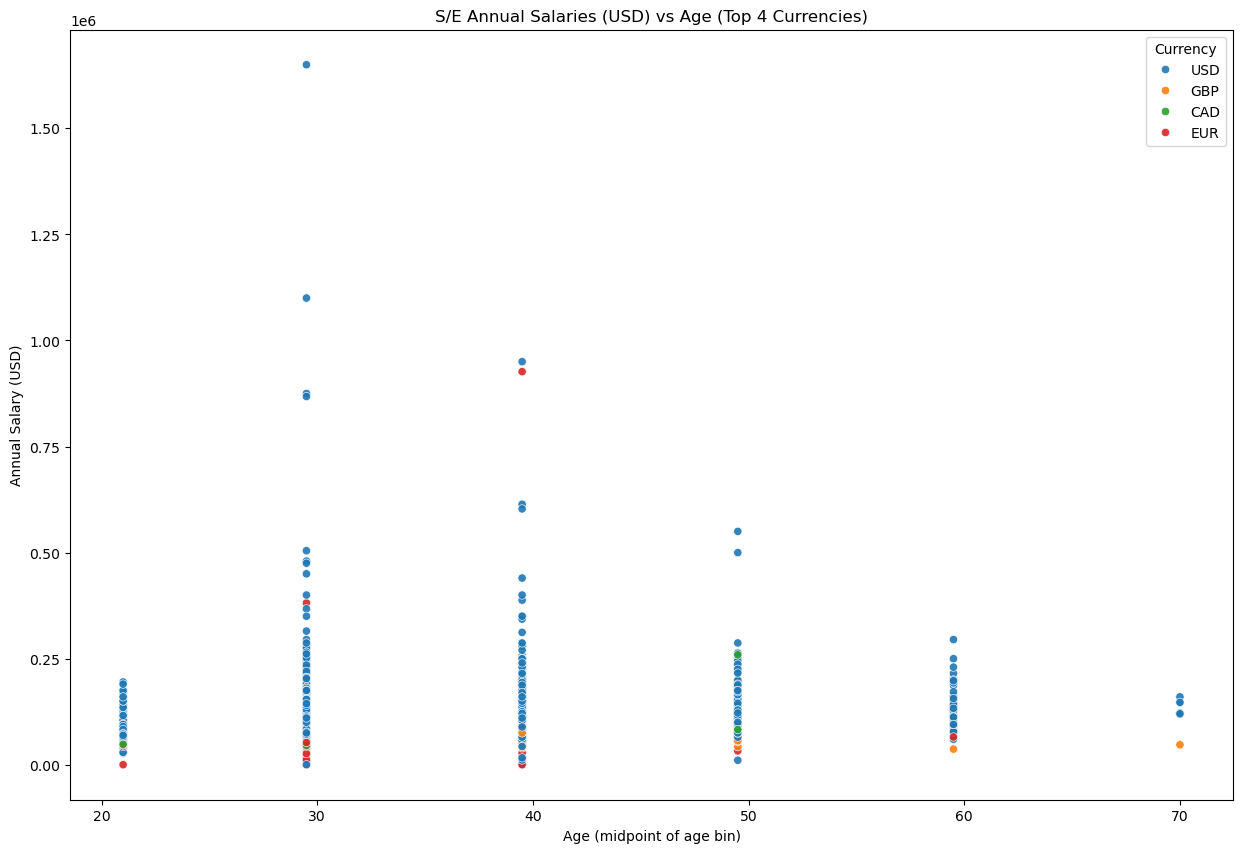

In [28]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_top4,
    x="Age midpoint",
    y="Annual salary USD",
    hue="Currency",
    alpha=0.9
)

plt.title("S/E Annual Salaries (USD) vs Age (Top 4 Currencies)")
plt.xlabel("Age (midpoint of age bin)")
plt.ylabel("Annual Salary (USD)")
plt.legend(title="Currency")
plt.show()